<a href="https://colab.research.google.com/github/UNCL3LO/TitanicSuvival-Analysis/blob/main/TitanicSuvival_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files

In [4]:
uploaded= files.upload()

Saving train.csv to train.csv


In [5]:
filename= list(uploaded.keys())[0]
df= pd.read_csv(filename)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
df[df['Age'].isnull()]['Name']

,Name
5,"Moran, Mr. James"
17,"Williams, Mr. Charles Eugene"
19,"Masselmani, Mrs. Fatima"
26,"Emir, Mr. Farred Chehab"
28,"O'Dwyer, Miss. Ellen ""Nellie"""
...,...
859,"Razi, Mr. Raihed"
863,"Sage, Miss. Dorothy Edith ""Dolly"""
868,"van Melkebeke, Mr. Philemon"
878,"Laleff, Mr. Kristo"


In [12]:
df['Age'].mode()

,Age
0,24.0


In [13]:
df['Age'].mean()

np.float64(29.69911764705882)

In [14]:
df['Age'].max()


80.0

In [15]:
df['Age'].min()

0.42

In [16]:
df['Age'].median()

28.0

In [17]:
df['Age'].fillna(df['Age'].median())

,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [18]:
df[df['Cabin'].isnull()]['Cabin']

,Cabin
0,NaN
2,NaN
4,NaN
5,NaN
7,NaN
...,...
884,NaN
885,NaN
886,NaN
888,NaN


In [19]:
df['Cabin']=df['Cabin'].fillna('Unknown')

In [20]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [21]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [22]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [23]:
df.groupby('Sex')['Survived'].sum()

,Survived
Sex,
female,233
male,109


In [40]:
Sexct=pd.crosstab(df['Sex'],df['Survived'])
print(Sexct)

Survived    0    1
Sex               
female     81  233
male      468  109


In [57]:
classct= pd.crosstab(df['Pclass'],df['Survived'])
print(ct)

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


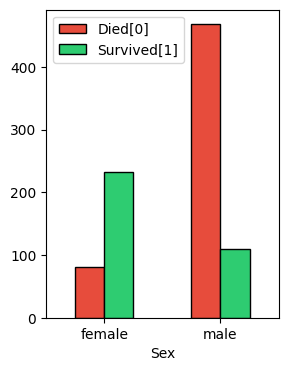

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

Sexct.plot(kind='bar', figsize=(3,4),color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.xticks(rotation=0)
plt.legend(['Died[0]', 'Survived[1]'])
plt.show()

Number of Males who died was significantly higher than number of females who died

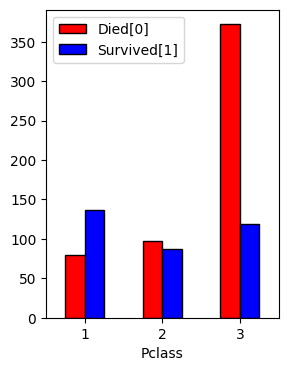

In [60]:
classct.plot(kind='bar',figsize=(3,4), color=['red','blue'],edgecolor='black')
plt.xticks(rotation=0)
plt.legend(['Died[0]','Survived[1]'])

plt.show()

Persons in class 3 had mortality rate twice as high as those in class 1 &2 combined

In [61]:
# 1. Define the age cutoffs
bins = [-1, 17, 35, 65, 120]

# 2. Define the corresponding labels
labels = ['Child', 'Youth', 'Adult', 'Elder']

# 3. Create the new column
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
df['Age_Group'].value_counts()



,count
Age_Group,
Youth,384
Adult,209
Child,113
Elder,8


In [64]:
AgeGroupct= pd.crosstab(df['Age_Group'],df['Survived'])
print(AgeGroupct)

Survived     0    1
Age_Group          
Child       52   61
Youth      238  146
Adult      127   82
Elder        7    1


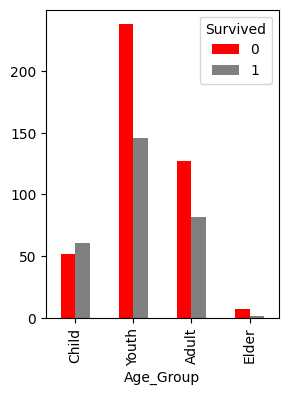

In [65]:
AgeGroupct.plot(kind='bar',figsize=(3,4), color=['red','grey'])
plt.show()

The youth made up the majority of loss of lives. This could also factored by the fact that they  made up the majority of the passengers

In [71]:
pd.crosstab(df['Age_Group'],df['Sex'],values=df['Survived'],aggfunc='sum')

Sex,female,male
Age_Group,,
Child,38,23
Youth,102,44
Adult,57,25
Elder,0,1


In [76]:
assct=pd.crosstab(
    index=df['Age_Group'],
    columns=[df['Sex'],df['Survived']],

)

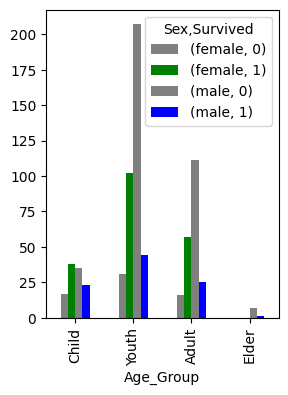

In [81]:
assct.plot(kind='bar',figsize=(3,4),color=['grey','green','grey','blue'])
plt.show()

Male Youth made up the greatest number of fatalities. Female elderly made up the least